In [1]:
import warnings
warnings.filterwarnings("ignore")

# Importing the Required Modules

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Loading the data in the form of DataFrame

In [3]:
df=pd.read_csv("/kaggle/input/life-expectancy/Life Expectancy Data.csv")
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# Extracting Info from the DataFrame loaded

In [4]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [6]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [7]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

# First we need to fill the NULL values

In [8]:
indices=df.isnull().sum()[df.isnull().sum()!=0].index
df[indices]=df[indices].fillna(df[indices].mean())

df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [9]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

# Missing Value Handling Done!

In [10]:
df['Status'].unique()

array(['Developing', 'Developed'], dtype=object)

# Dropping the Country as already covered by Status

In [11]:
df=df.drop(columns=['Country'])
df.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# Encoding the status for feeding it in the model

In [12]:
df['Status']=pd.get_dummies(df['Status'],drop_first=True,dtype=int)
df.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# Now we need to find the outliers very much

In [13]:
columns_for_outliers=list(df.select_dtypes(include=['number']).columns)
columns_for_outliers.remove('Status')
columns_for_outliers

['Year',
 'Life expectancy ',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles ',
 ' BMI ',
 'under-five deaths ',
 'Polio',
 'Total expenditure',
 'Diphtheria ',
 ' HIV/AIDS',
 'GDP',
 'Population',
 ' thinness  1-19 years',
 ' thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

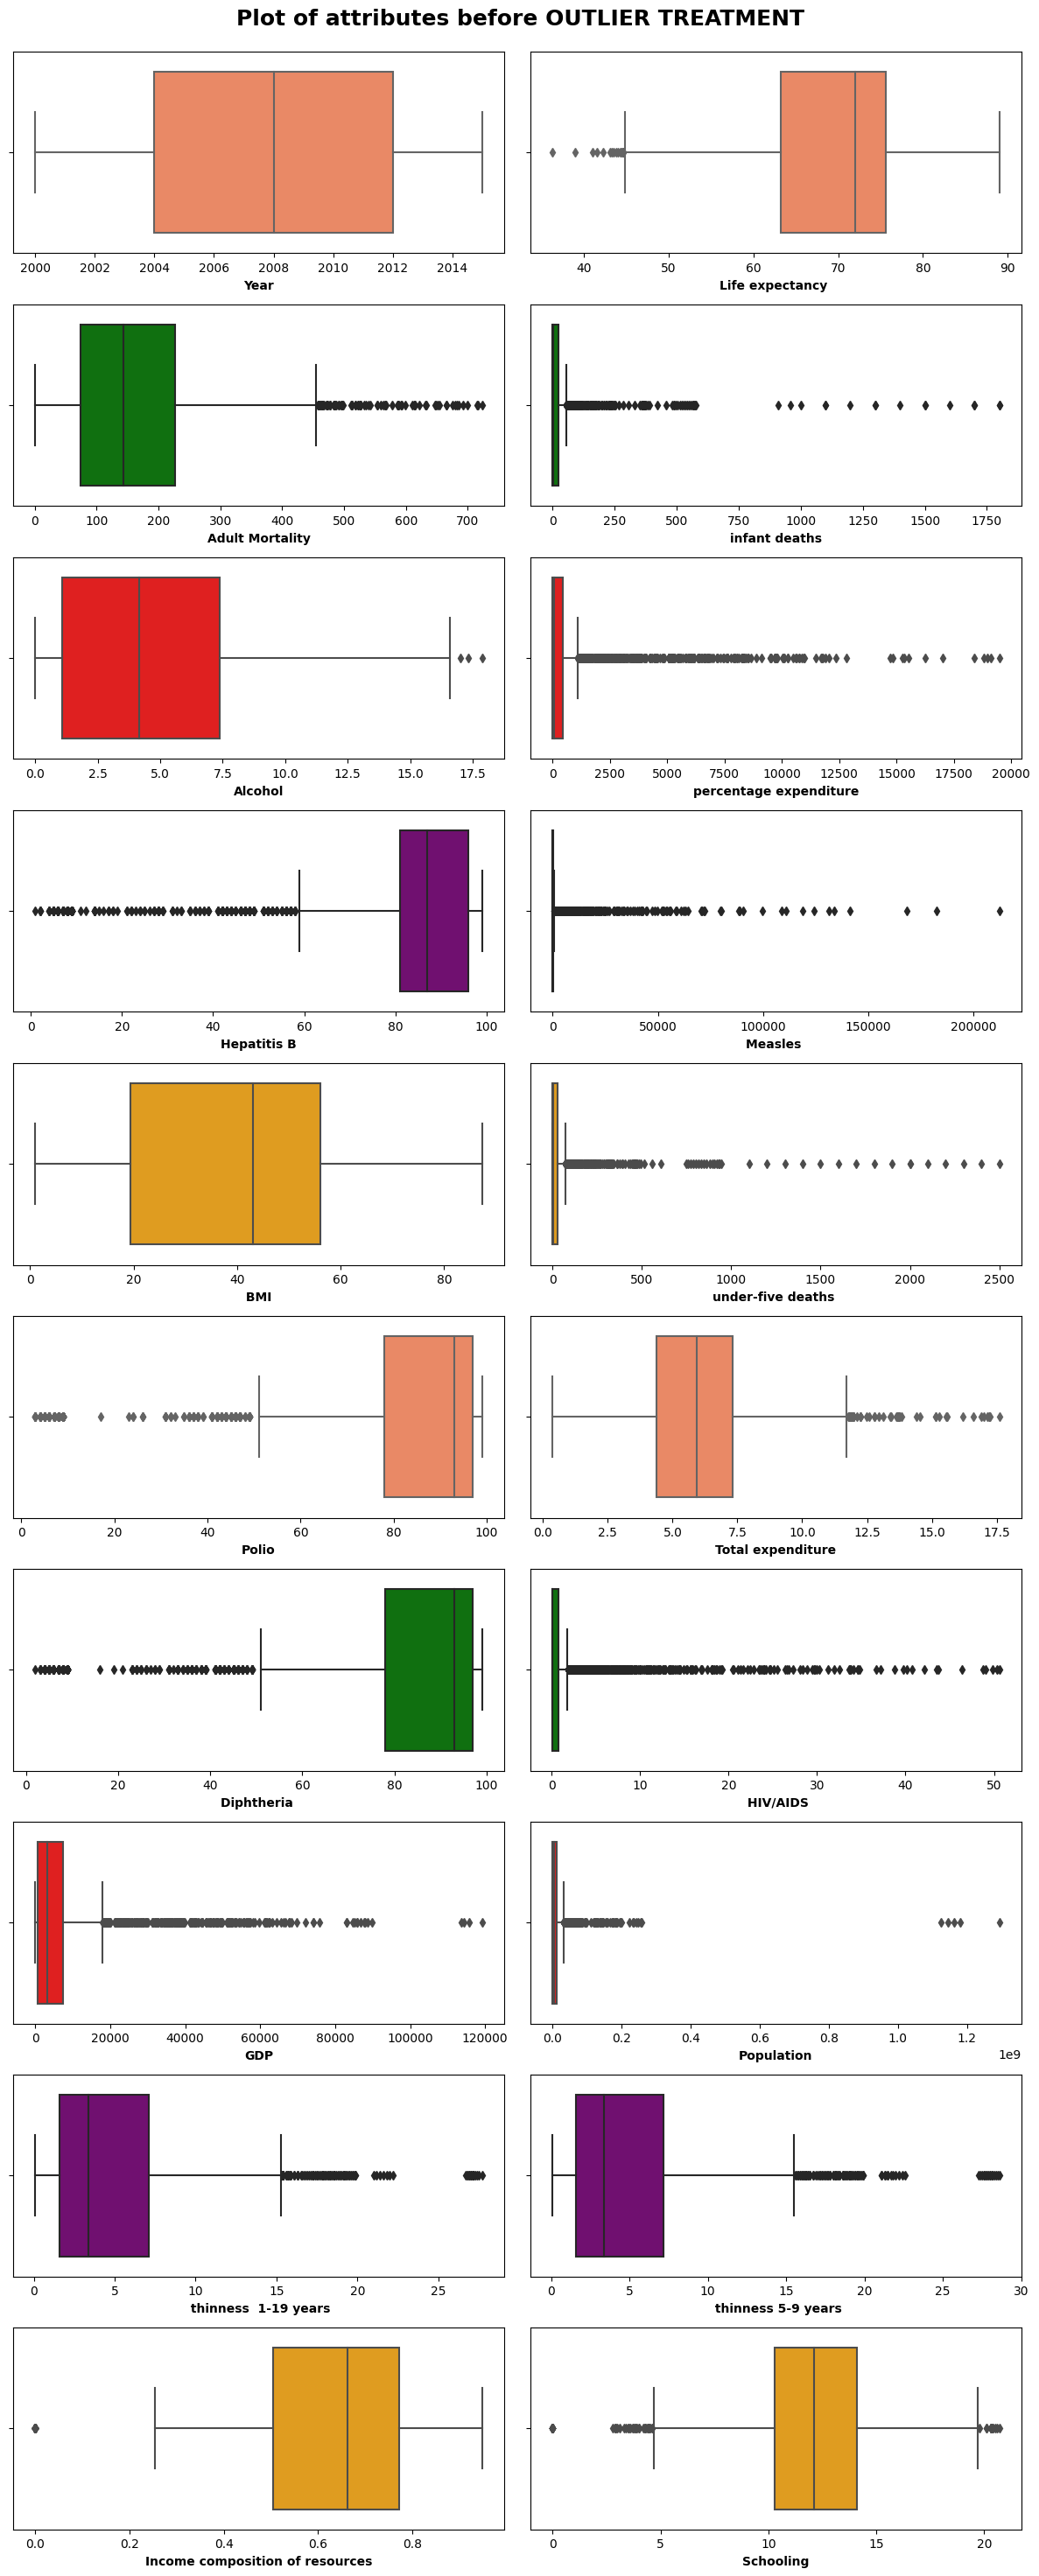

In [14]:
fig,axes= plt.subplots(10,2,figsize=(12,30))
axes=axes.flatten()

colour=['coral','green','red','purple','orange']*4

for element in range(len(columns_for_outliers)):
    sns.boxplot(x=df[columns_for_outliers[element]],ax=axes[element],color=colour[element//2])
    axes[element].set_xlabel(columns_for_outliers[element],fontweight='bold')
plt.suptitle("Plot of attributes before OUTLIER TREATMENT\n\n",fontweight='bold',fontsize=18)
plt.tight_layout() 
plt.show()

# Outliers are there! We gonna remove it

In [15]:
for column in columns_for_outliers:
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1

    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    df[column]=df[column].clip(lower_bound,upper_bound)

# Visualization after OUTLIER removal

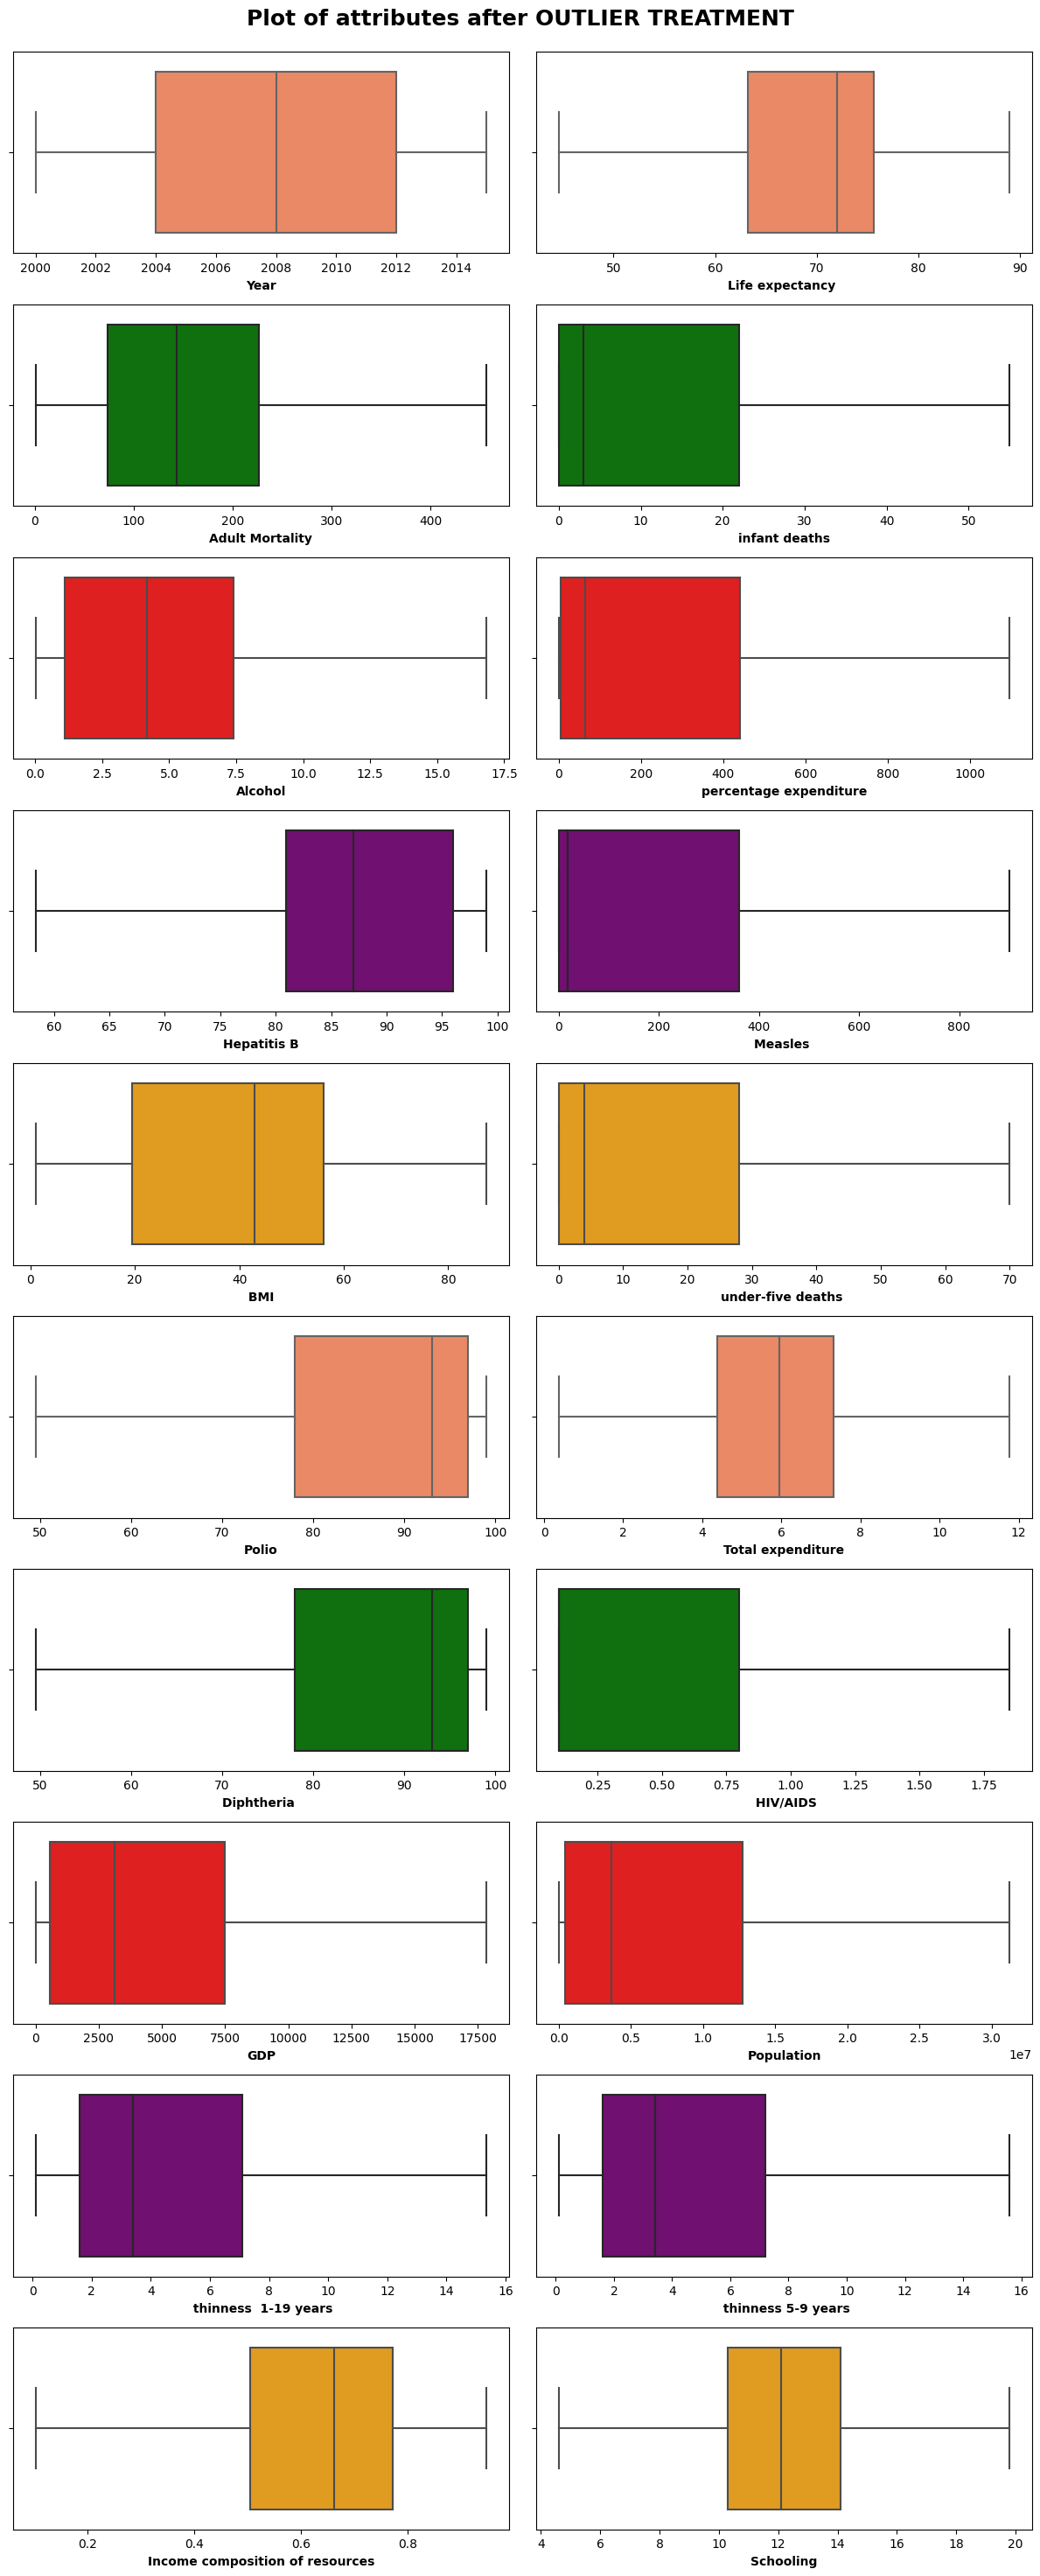

In [16]:
fig,axes= plt.subplots(10,2,figsize=(12,30))
axes=axes.flatten()

colour=['coral','green','red','purple','orange']*4

for element in range(len(columns_for_outliers)):
    sns.boxplot(x=df[columns_for_outliers[element]],ax=axes[element],color=colour[element//2])
    axes[element].set_xlabel(columns_for_outliers[element],fontweight='bold')
plt.suptitle("Plot of attributes after OUTLIER TREATMENT\n\n",fontweight='bold',fontsize=18)
plt.tight_layout() 
plt.show()

In [17]:
# Keep original dataframe copy for plotting
df_plot = df.copy()

# Its time for Scaling them before training the model

In [18]:
scaler= StandardScaler()

In [19]:
df.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,65.0,263.0,55,0.01,71.279624,65.0,900.625,19.1,...,49.5,8.16,65.0,0.1,584.259210,3.125506e+07,15.35,15.6,0.479,10.1
1,2014,1,59.9,271.0,55,0.01,73.523582,62.0,492.000,18.6,...,58.0,8.18,62.0,0.1,612.696514,3.275820e+05,15.35,15.6,0.476,10.0
2,2013,1,59.9,268.0,55,0.01,73.219243,64.0,430.000,18.1,...,62.0,8.13,64.0,0.1,631.744976,3.125506e+07,15.35,15.6,0.470,9.9
3,2012,1,59.5,272.0,55,0.01,78.184215,67.0,900.625,17.6,...,67.0,8.52,67.0,0.1,669.959000,3.696958e+06,15.35,15.6,0.463,9.8
4,2011,1,59.2,275.0,55,0.01,7.097109,68.0,900.625,17.2,...,68.0,7.87,68.0,0.1,63.537231,2.978599e+06,15.35,15.6,0.454,9.5


In [20]:
Life_expectancy_mean= df['Life expectancy '].mean()
Life_expectancy_std= df['Life expectancy '].std()

In [21]:
df[columns_for_outliers]=pd.DataFrame(scaler.fit_transform(df[columns_for_outliers]),columns=columns_for_outliers)
df.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,1.621762,1,-0.446803,0.874521,2.165057,-1.173361,-0.546410,-1.534064,1.886225,-0.964715,...,-2.265630,0.985324,-1.282382,-0.629209,-0.814796,2.650045,2.708884,2.737658,-0.799320,-0.626982
1,1.404986,1,-0.984892,0.943807,2.165057,-1.173361,-0.540647,-1.768413,0.730456,-0.989810,...,-1.727535,0.994061,-1.472525,-0.629209,-0.809714,-0.826718,2.708884,2.737658,-0.814983,-0.659237
2,1.188210,1,-0.984892,0.917824,2.165057,-1.173361,-0.541429,-1.612181,0.555093,-1.014905,...,-1.474314,0.972218,-1.345763,-0.629209,-0.806310,2.650045,2.708884,2.737658,-0.846310,-0.691493
3,0.971434,1,-1.027095,0.952467,2.165057,-1.173361,-0.528678,-1.377832,1.886225,-1.040000,...,-1.157788,1.142595,-1.155619,-0.629209,-0.799482,-0.447944,2.708884,2.737658,-0.882859,-0.723749
4,0.754658,1,-1.058747,0.978449,2.165057,-1.173361,-0.711239,-1.299715,1.886225,-1.060076,...,-1.094482,0.858634,-1.092238,-0.629209,-0.907849,-0.528699,2.708884,2.737658,-0.929849,-0.820516


# Scaling Done :)

# Splitting the dataset for training

In [22]:
target=df['Life expectancy ']
df=df.drop(columns=['Life expectancy '])

In [23]:
x_train,x_test,y_train,y_test=train_test_split(df,target,test_size=0.20,random_state=42)

# Building and training the model

In [24]:
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [25]:
model = LinearRegression()
model.fit(x_train_poly, y_train)

LinearRegression()

# Predicting with the model built so far

In [26]:
y_train_pred = model.predict(x_train_poly)
y_test_pred = model.predict(x_test_poly)

# Comparison of the Predicted and Actual Values

In [27]:
result_1=(pd.Series(y_test_pred).reset_index().drop(columns=['index'])*Life_expectancy_std)+Life_expectancy_mean
result_1.columns=['Predicted_Values']

result_2=(y_test.reset_index().drop(columns=['index'])*Life_expectancy_std)+Life_expectancy_mean

comparison=pd.concat((result_1,result_2),axis=1)
comparison.head()

,Predicted_Values,Life expectancy
0,71.988021,73.700760
1,77.020304,75.901135
2,75.718188,74.200845
3,77.288770,76.801288
4,50.872104,51.897049


# Evaluating the model 

In [28]:
print(":::Model Performance:::")
print()
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

:::Model Performance:::

Train R2: 0.9350963081156903
Test R2: 0.9325132709104929
Train MSE: 0.06549402514313957
Test MSE: 0.06498995865837616


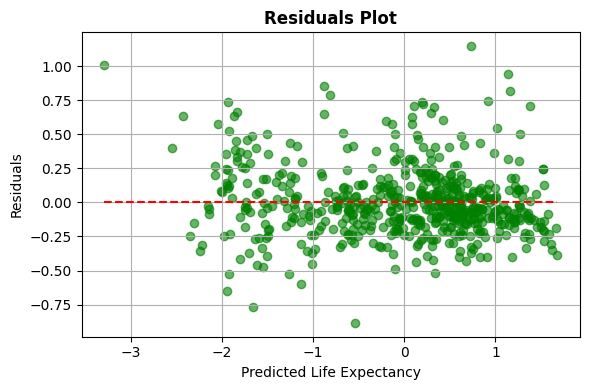

In [29]:
residuals = y_test-y_test_pred
plt.figure(figsize=(6,4))
plt.scatter(y_test_pred, residuals, color='green', alpha=0.6)
plt.hlines(0, y_test_pred.min(), y_test_pred.max(), colors='red', linestyles='dashed')
plt.xlabel('Predicted Life Expectancy')
plt.ylabel('Residuals')
plt.title('Residuals Plot',fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

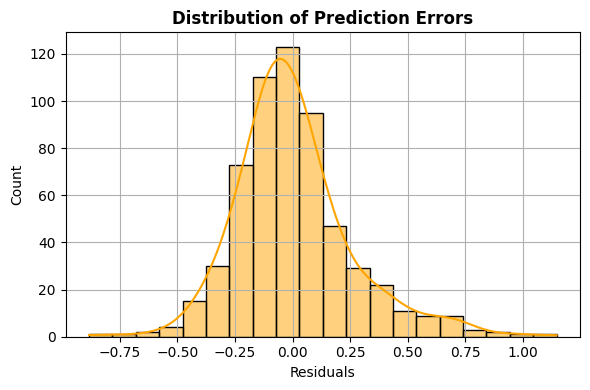

In [30]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, color='orange', bins=20)
plt.xlabel('Residuals')
plt.title('Distribution of Prediction Errors',fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

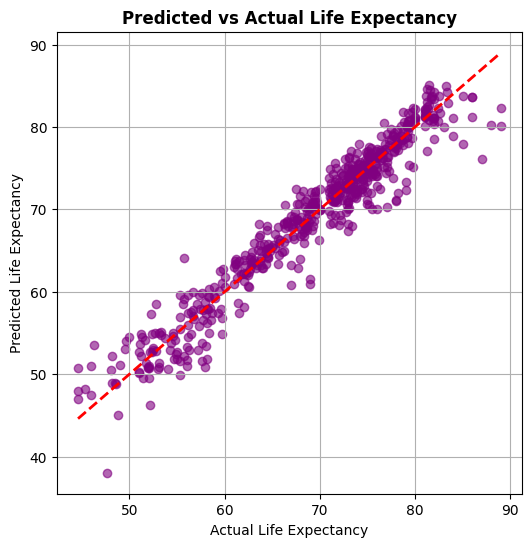

In [31]:
y_pred = comparison.iloc[:, 0].values 
y_actual = comparison.iloc[:, 1].values 

plt.figure(figsize=(6,6))
plt.scatter(y_actual, y_pred, color='purple', alpha=0.6)
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Predicted vs Actual Life Expectancy',fontweight='bold')
plt.grid(True)
plt.show()

# Thanks :)